# Section 7: Univariate Analysis
### EDA Notebook 01 — Insurance Claims Fraud Detection Project
**University of Ghana | DSA Final Year Project | AY 2025/2026**

---

## Section Goal
Understand the **standalone distribution of each feature** — both numerical and categorical — before introducing the target variable.  
This establishes the statistical baseline for all fraud-focused analysis in Sections 8–14.

> Univariate analysis answers: *"What does each feature look like on its own?"*  
> It reveals skewness, zero-inflation, rare categories, and distributional anomalies that will guide transformation and modelling decisions later.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100

df = pd.read_csv('../data/cleaned/insurance_claims_cleaned.csv')
print(f"Dataset loaded: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"Fraud: {df['fraud_reported'].sum()} ({df['fraud_reported'].mean()*100:.1f}%)  |  Non-Fraud: {(df['fraud_reported']==0).sum()} ({(df['fraud_reported']==0).mean()*100:.1f}%)")


Dataset loaded: 1000 rows × 39 columns
Fraud: 247 (24.7%)  |  Non-Fraud: 753 (75.3%)


## Subsection A — Numerical Feature Distributions

### Why histograms + KDE, not just boxplots?
Boxplots summarise a distribution via five statistics but **hide multimodality and the full shape of the tail**.  
Histograms with KDE overlays reveal whether a distribution is unimodal, bimodal, or heavily zero-inflated — all of which matter for fraud:
- A bimodal `total_claim_amount` could reveal two distinct fraud types (exaggerated minor accidents vs staged total losses).
- Zero-inflated `umbrella_limit` reflects the opt-in nature of that coverage (79.8% zeros, as per teammate's analysis).
- Extreme right tails in claim components could flag fraud-driven inflation.

The NUS benchmark group also used histograms to assess skewness before deciding on normalisation strategies. Boxplots are reserved for bivariate comparison (Section 8).

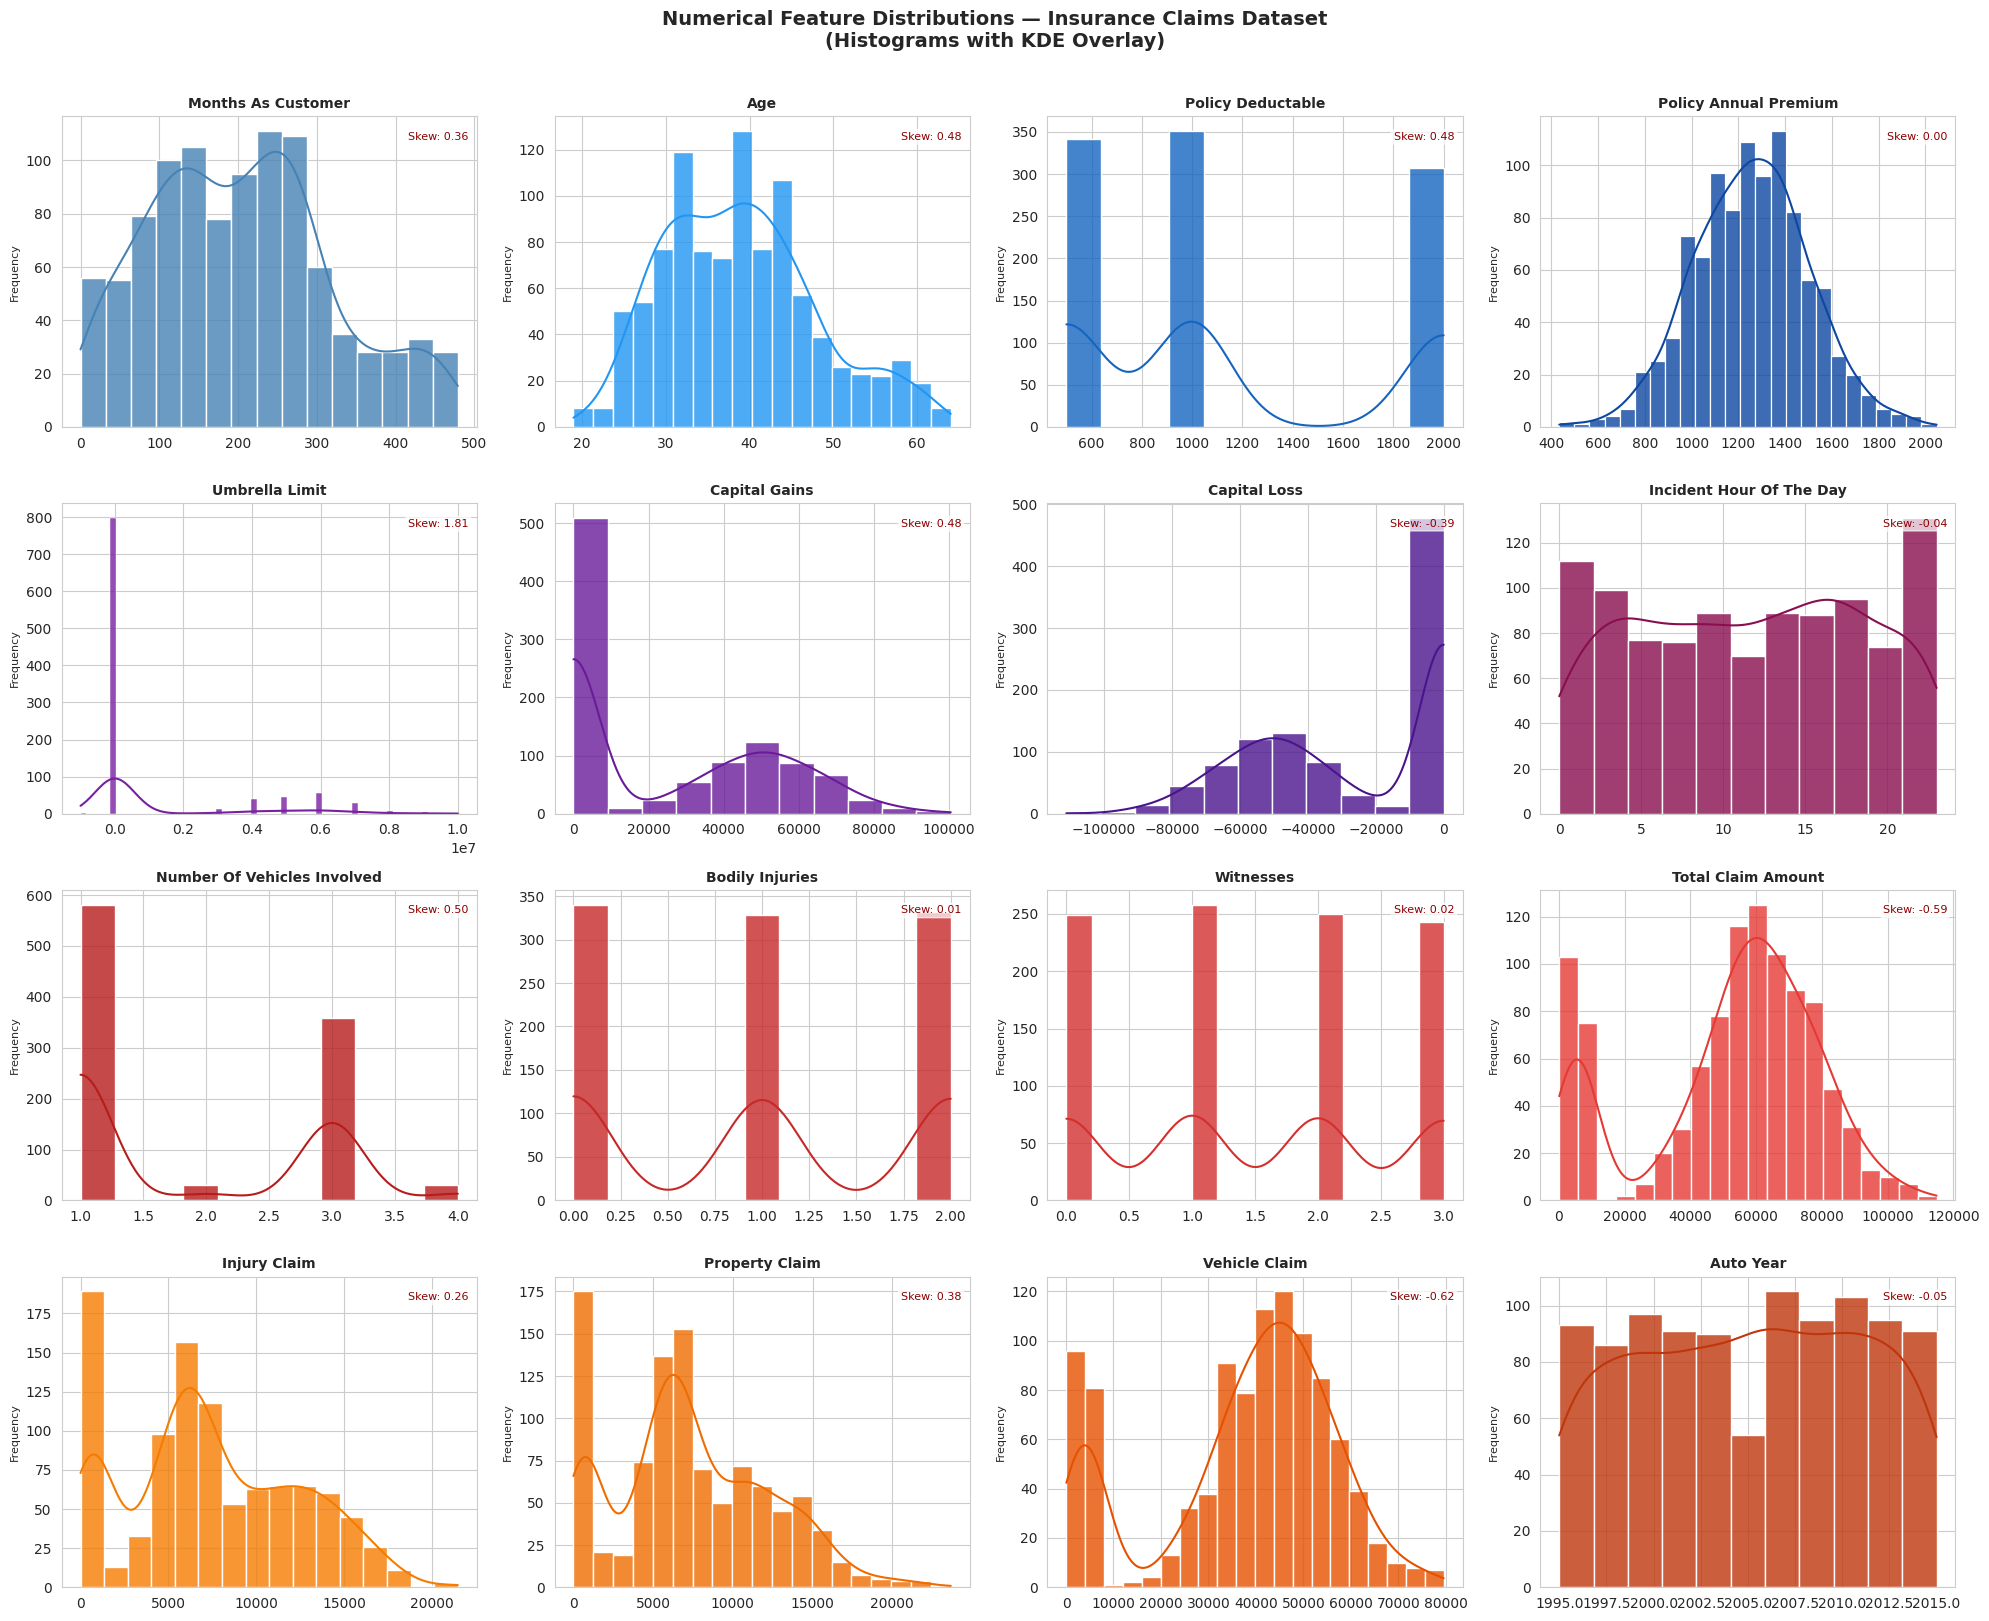

Figure saved: 01_numerical_distributions.png


In [2]:
num_cols = ['months_as_customer','age','policy_deductable','policy_annual_premium',
            'umbrella_limit','capital_gains','capital_loss','incident_hour_of_the_day',
            'number_of_vehicles_involved','bodily_injuries','witnesses',
            'total_claim_amount','injury_claim','property_claim','vehicle_claim','auto_year']

fig, axes = plt.subplots(4, 4, figsize=(20, 16))
axes = axes.flatten()

palette_colors = ['steelblue','#2196F3','#1565C0','#0D47A1',
                  '#7B1FA2','#6A1B9A','#4A148C','#880E4F',
                  '#B71C1C','#C62828','#D32F2F','#E53935',
                  '#F57C00','#EF6C00','#E65100','#BF360C']

for i, col in enumerate(num_cols):
    color = palette_colors[i % len(palette_colors)]
    sns.histplot(df[col], kde=True, ax=axes[i], color=color, edgecolor='white', alpha=0.8)
    axes[i].set_title(col.replace('_', ' ').title(), fontsize=10, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Frequency', fontsize=8)
    skewness = df[col].skew()
    axes[i].annotate(f'Skew: {skewness:.2f}', xy=(0.98, 0.95), xycoords='axes fraction',
                     ha='right', va='top', fontsize=8, color='darkred',
                     bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7))

plt.suptitle('Numerical Feature Distributions — Insurance Claims Dataset\n(Histograms with KDE Overlay)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../reports/figures/01_numerical_distributions.png', dpi=300, bbox_inches='tight')
plt.show()
print("Figure saved: 01_numerical_distributions.png")


### Percentile Analysis

#### Why the 99th percentile alongside the 75th?
The standard IQR rule (1.5×IQR above Q3) catches moderate outliers but **misses the extreme tail behaviour relevant to fraud**.  
Claim fraud often involves amounts at the very top of the distribution. The 95th and 99th percentiles flag these extremes without discarding them prematurely.  
A `total_claim_amount` at the 99th percentile may be 2-3× the median — precisely the economic motive for staging a fraud claim.

In [3]:
percentiles = [0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
pct_df = df[num_cols].quantile(percentiles).T
pct_df.columns = ['P1','P5','P25','P50 (Median)','P75','P95','P99']
pct_df['Skewness'] = df[num_cols].skew().round(3)
pct_df['Kurtosis'] = df[num_cols].kurt().round(3)

print("=== Percentile Analysis — Numerical Features ===")
print(pct_df.round(2).to_string())
print()

# Flag extreme tails
print("=== EXTREME TAIL FLAGS ===")
for col in num_cols:
    p75 = df[col].quantile(0.75)
    p99 = df[col].quantile(0.99)
    p1 = df[col].quantile(0.01)
    p25 = df[col].quantile(0.25)
    if p75 > 0 and p99 > p75 * 3:
        print(f"  RIGHT TAIL: {col} — P99={p99:,.0f} vs P75={p75:,.0f} (ratio={p99/p75:.1f}×)")
    if p25 != 0 and abs(p1) > abs(p25) * 3:
        print(f"  LEFT TAIL:  {col} — P1={p1:,.0f} vs P25={p25:,.0f}")


=== Percentile Analysis — Numerical Features ===
                                   P1        P5       P25  P50 (Median)       P75         P95         P99  Skewness  Kurtosis
months_as_customer               4.00     28.90    115.75         199.5    276.25      429.05      467.01      0.36     -0.48
age                             23.00     26.00     32.00          38.0     44.00       57.00       61.00      0.48     -0.26
policy_deductable              500.00    500.00    500.00        1000.0   2000.00     2000.00     2000.00      0.48     -1.38
policy_annual_premium          694.22    855.11   1089.61        1257.2   1415.70     1653.44     1851.88      0.00      0.07
umbrella_limit                   0.00      0.00      0.00           0.0      0.00  6000000.00  8000000.00      1.81      1.79
capital_gains                    0.00      0.00      0.00           0.0  51025.00    70615.00    83603.00      0.48     -1.28
capital_loss                -85914.00 -72305.00 -51500.00      -23250

### Zero-Inflation Analysis

Zero-inflated features require special handling:
- **Statistical**: standard scaling is distorted when 50%+ of values are zero.
- **Modelling**: tree models handle zeros well, but linear models (Logistic Regression) may need log1p transformation.
- **Fraud signal**: `witnesses = 0` was flagged by the team as a potential fraud signal (24.9% of claims).

=== ZERO-INFLATION SUMMARY ===
                          zero_count  zero_pct  negative_count
umbrella_limit                   798      79.8               1
capital_gains                    508      50.8               0
capital_loss                     475      47.5             525
bodily_injuries                  340      34.0               0
witnesses                        249      24.9               0
incident_hour_of_the_day          52       5.2               0
injury_claim                      25       2.5               0
property_claim                    19       1.9               0
months_as_customer                 1       0.1               0


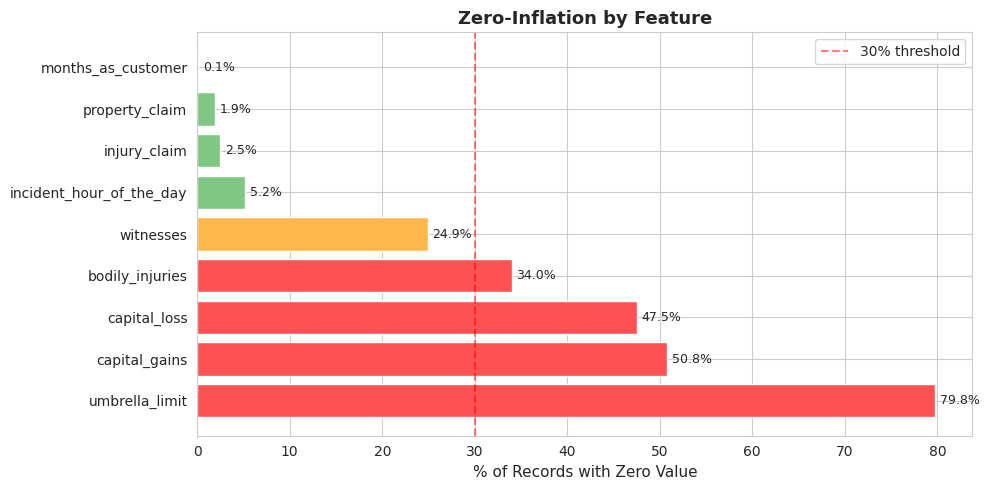

In [4]:
zero_df = pd.DataFrame({
    'zero_count': (df[num_cols] == 0).sum(),
    'zero_pct': ((df[num_cols] == 0).sum() / len(df) * 100).round(2),
    'negative_count': (df[num_cols] < 0).sum()
}).sort_values('zero_pct', ascending=False)

print("=== ZERO-INFLATION SUMMARY ===")
print(zero_df[zero_df['zero_count'] > 0].to_string())

# Visualise zero-inflation
zero_plot = zero_df[zero_df['zero_count'] > 0].copy()
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#FF5252' if p > 30 else '#FFB74D' if p > 10 else '#81C784'
          for p in zero_plot['zero_pct']]
bars = ax.barh(zero_plot.index, zero_plot['zero_pct'], color=colors, edgecolor='white')
ax.set_xlabel('% of Records with Zero Value', fontsize=11)
ax.set_title('Zero-Inflation by Feature', fontsize=13, fontweight='bold')
for bar, val in zip(bars, zero_plot['zero_pct']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9)
ax.axvline(x=30, color='red', linestyle='--', alpha=0.5, label='30% threshold')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/figures/01_zero_inflation.png', dpi=300, bbox_inches='tight')
plt.show()


## Subsection B — Categorical Feature Distributions

### Why horizontal bar charts, not pie charts?
Pie charts make it difficult to compare slice sizes when categories are close in frequency and become **illegible beyond 6-7 categories**. Most of our categorical features have 4–20 levels. Horizontal bar charts with the exact count and percentage annotated allow precise comparison. They also make it immediately obvious if one category dominates — a fraud signal in itself.

### Why sort by frequency descending?
Sorting by frequency gives a natural **Pareto view** — the analyst immediately sees which categories drive the most volume, and later in Section 8 we can ask: of this high-volume category, what is the fraud rate? The combination of volume and fraud rate is the key fraud prioritisation lens.

In [5]:
cat_cols = ['policy_state','policy_csl','insured_sex','insured_education_level',
            'insured_occupation','insured_hobbies','insured_relationship',
            'incident_type','collision_type','incident_severity',
            'authorities_contacted','incident_state','property_damage',
            'police_report_available','auto_make','auto_model']

# Summary table
cat_summary = pd.DataFrame({
    'unique_count': df[cat_cols].nunique(),
    'top_category': [df[c].value_counts().index[0] for c in cat_cols],
    'top_freq': [df[c].value_counts().iloc[0] for c in cat_cols],
    'top_pct': [(df[c].value_counts().iloc[0]/len(df)*100).round(2) for c in cat_cols],
    'rare_categories': [sum(df[c].value_counts() < 20) for c in cat_cols]
})
print("=== CATEGORICAL FEATURES SUMMARY ===")
print(cat_summary.to_string())


=== CATEGORICAL FEATURES SUMMARY ===
                         unique_count             top_category  top_freq  top_pct  rare_categories
policy_state                        3                       OH       352     35.2                0
policy_csl                          3                  250/500       351     35.1                0
insured_sex                         2                   Female       537     53.7                0
insured_education_level             7                       JD       161     16.1                0
insured_occupation                 14        machine-op-inspct        93      9.3                0
insured_hobbies                    20                  reading        64      6.4                0
insured_relationship                6                own-child       183     18.3                0
incident_type                       4  Multi-vehicle Collision       419     41.9                0
collision_type                      4           Rear Collision       292

/tmp/ipykernel_633/1964794362.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=val_counts.values, y=val_counts.index,
/tmp/ipykernel_633/1964794362.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=val_counts.values, y=val_counts.index,
/tmp/ipykernel_633/1964794362.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=val_counts.values, y=val_counts.index,
/tmp/ipykernel_633/1964794362.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` 

/tmp/ipykernel_633/1964794362.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=val_counts.values, y=val_counts.index,
/tmp/ipykernel_633/1964794362.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=val_counts.values, y=val_counts.index,
/tmp/ipykernel_633/1964794362.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=val_counts.values, y=val_counts.index,


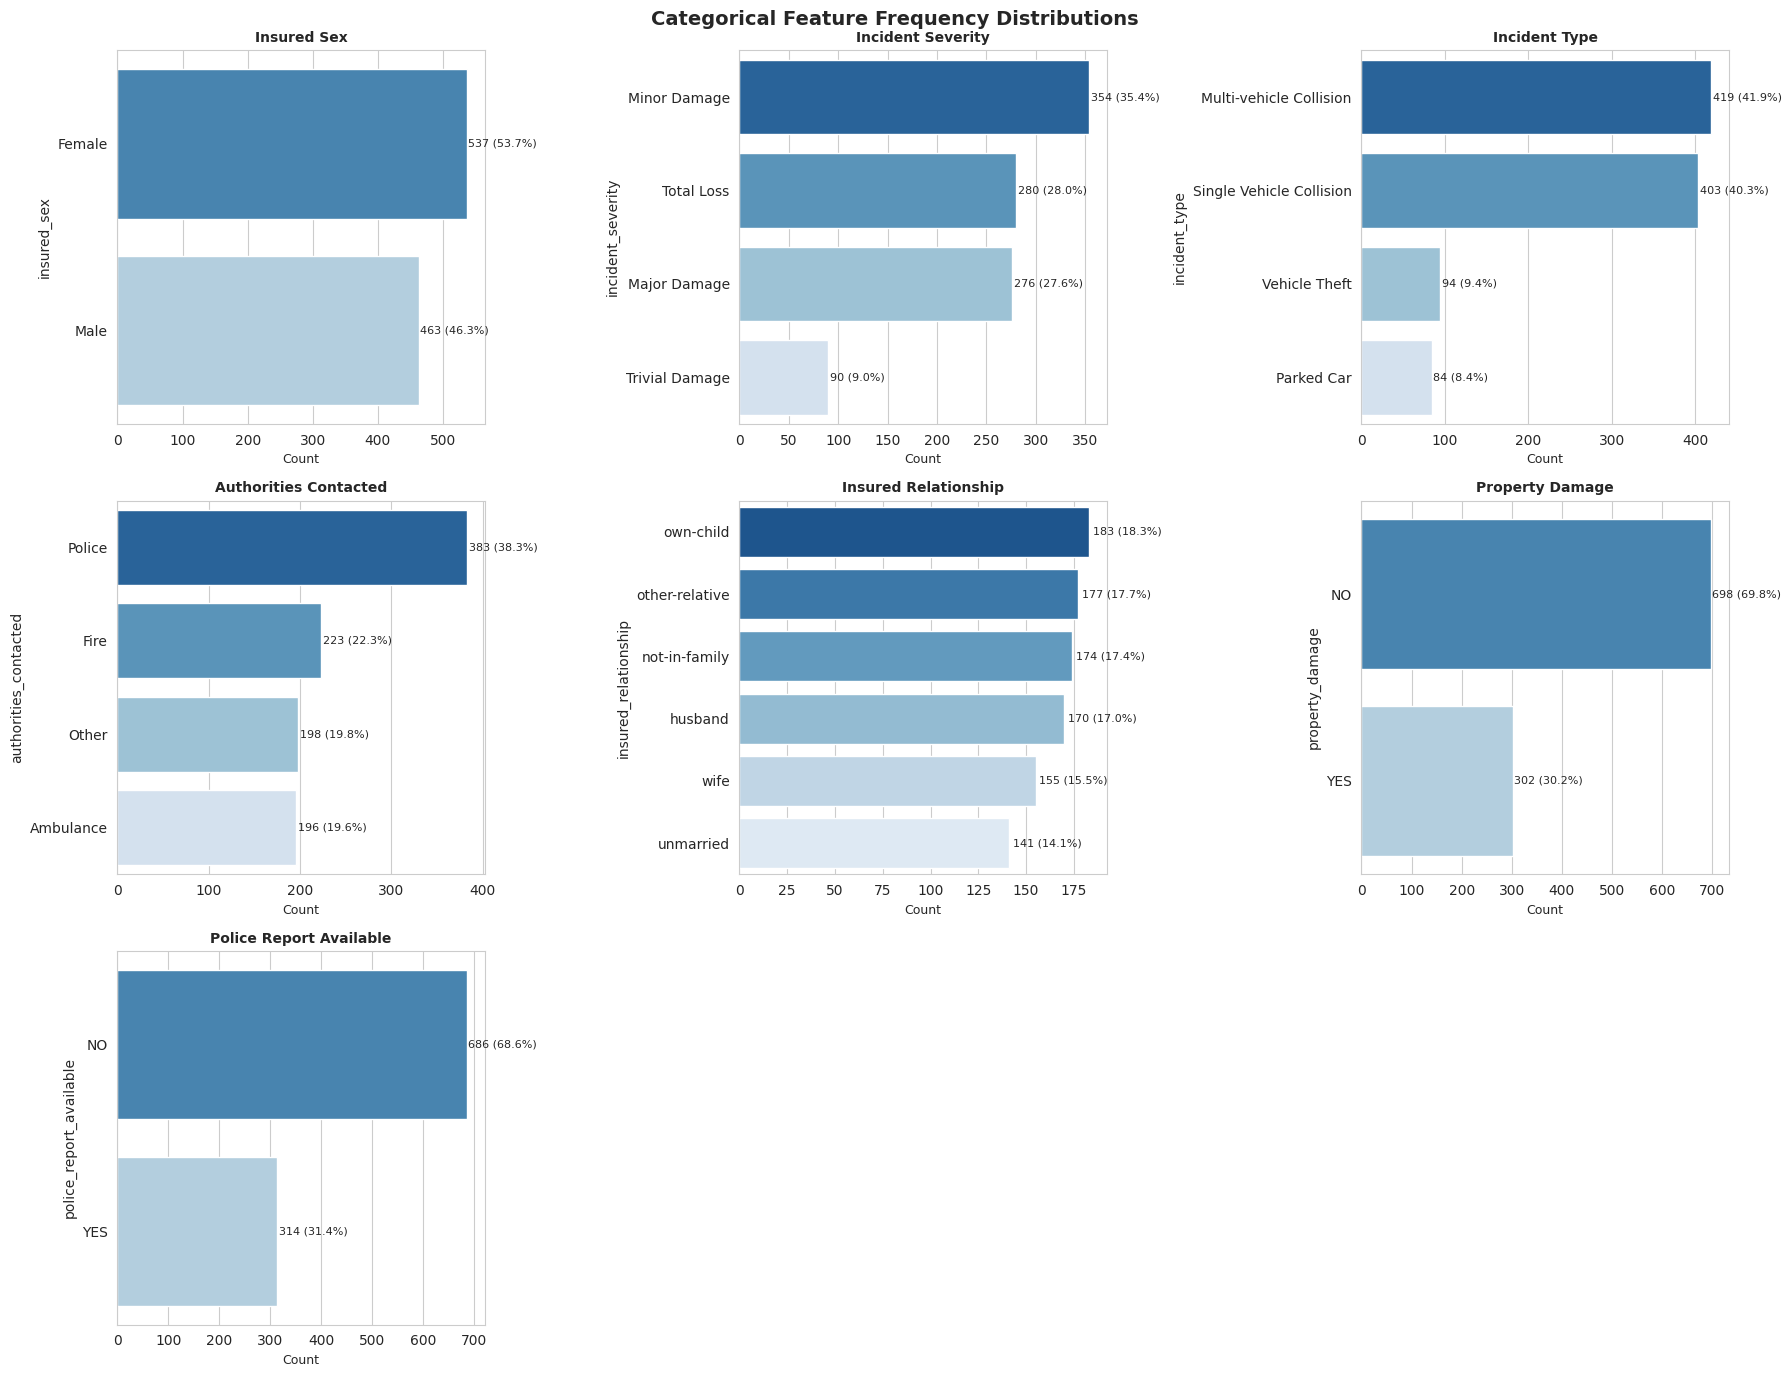

In [6]:
# Individual frequency bar charts for key categoricals (compact set)
key_cats = ['insured_sex','incident_severity','incident_type','authorities_contacted',
            'insured_relationship','property_damage','police_report_available']

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

for i, col in enumerate(key_cats):
    val_counts = df[col].value_counts()
    ax = axes[i]
    sns.barplot(x=val_counts.values, y=val_counts.index,
                palette=sns.color_palette('Blues_r', len(val_counts)), ax=ax)
    ax.set_title(f'{col.replace("_"," ").title()}', fontweight='bold', fontsize=10)
    ax.set_xlabel('Count', fontsize=9)
    for j, v in enumerate(val_counts.values):
        ax.text(v + 2, j, f'{v} ({v/len(df)*100:.1f}%)', va='center', fontsize=8)

# Hide unused subplots
for k in range(len(key_cats), len(axes)):
    axes[k].set_visible(False)

plt.suptitle('Categorical Feature Frequency Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/01_categorical_key.png', dpi=300, bbox_inches='tight')
plt.show()


/tmp/ipykernel_633/939803626.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=val_counts.values, y=val_counts.index,
/tmp/ipykernel_633/939803626.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=val_counts.values, y=val_counts.index,


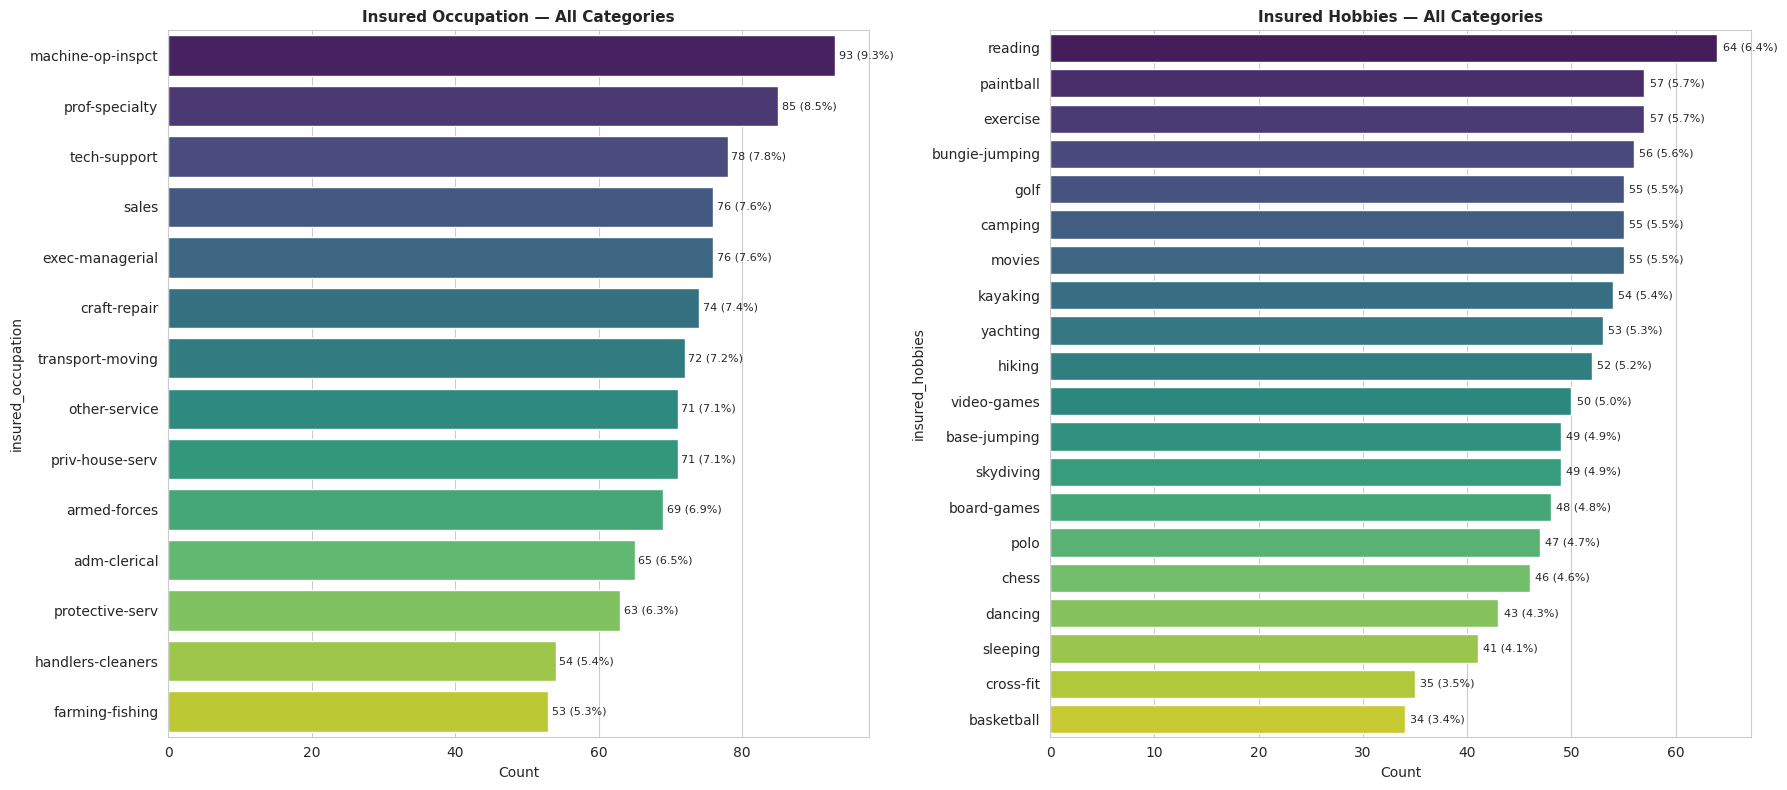

=== RARE CATEGORY FLAGS (< 2% of observations) ===
  auto_model: ['3 Series', 'C300', 'X6', 'M5', 'Accord', 'RSX'] → candidates for grouping in Feature Engineering


In [7]:
# High-cardinality features: insured_occupation and insured_hobbies
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

for ax, col in zip(axes, ['insured_occupation', 'insured_hobbies']):
    val_counts = df[col].value_counts()
    sns.barplot(x=val_counts.values, y=val_counts.index,
                palette=sns.color_palette('viridis', len(val_counts)), ax=ax)
    ax.set_title(f'{col.replace("_"," ").title()} — All Categories', fontweight='bold', fontsize=11)
    ax.set_xlabel('Count')
    for j, v in enumerate(val_counts.values):
        ax.text(v + 0.5, j, f'{v} ({v/len(df)*100:.1f}%)', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('../reports/figures/01_highcardinality_cats.png', dpi=300, bbox_inches='tight')
plt.show()

# Flag rare categories (< 2% = < 20 records)
print("=== RARE CATEGORY FLAGS (< 2% of observations) ===")
for col in cat_cols:
    rare = df[col].value_counts()[df[col].value_counts() < 20]
    if len(rare) > 0:
        print(f"  {col}: {list(rare.index)} → candidates for grouping in Feature Engineering")


## Key Fraud Insights — Section 7

### What the Univariate Distributions Reveal About the Data

1. **Claim components are heavily right-skewed**: `total_claim_amount`, `injury_claim`, `vehicle_claim`, and `property_claim` all show right-skewed distributions — consistent with most claims being moderate but a tail of extremely large claims. These right-tail observations are likely fraud candidates (economic motivation theory).

2. **Zero-inflation is a defining characteristic of three features**: `umbrella_limit` (79.8% zeros), `capital_gains` (~50.8% zeros), and `capital_loss` (~47.5% zeros). These features require careful treatment before modelling, especially for Logistic Regression which is sensitive to distributional assumptions.

3. **`umbrella_limit` has negative values** (minimum = -1,000,000) — these represent liability caps, not data errors. This was correctly noted by the teammate and must be preserved.

4. **`witnesses = 0` in approximately 24.9% of claims** — this is the key standalone fraud signal. A claim with no witnesses is harder to refute, lowering the perceived risk for a fraudster.

5. **`incident_severity` is approximately evenly distributed** across Major, Minor, Trivial Damage and Total Loss — no single category dominates, meaning the fraud rate *within* each category (Section 8) is the key question.

6. **`insured_hobbies` has chess and cross-fit as mid-frequency categories** (neither dominant nor rare). Their fraud rate anomaly, confirmed by NUS, will be examined in Section 8.

7. **`auto_make` includes European luxury brands (BMW, Mercedes, Audi)** at moderate frequencies — the NUS finding that European brands correlate with higher fraud rates will be tested in Section 12 Feature Engineering.

8. **`collision_type` includes "Not Applicable"** as a common value (vehicle theft and parked car incidents have no collision type) — this must be handled correctly in one-hot encoding to avoid a false signal.

> **Next Step:** Section 8 (Bivariate Analysis) will cross-reference each of these distributions against `fraud_reported` to identify which features are statistically significant fraud signals.